# Data Samples

This notebook shows how to deal with the data samples and reports the available ones.
All the following samples have been produced with an [AnalysisProduction](https://lhcb-ap.docs.cern.ch/)(AP) to create the tuples and store them on the GRID.
For simplicity a file for each sample has been saved to disk on the `pearly-gates` server for a preliminary analysis.

Once the preliminary analysis is done, another AP with a refined selection will be prepared.

## Data

Data has been recorded by the LHCb detector during Run3 of LHC (2024-2026).
In these files, the candidates passing the HLT2 $\tau\to\mu\mu\mu$ and $D^+_s\to\phi(\mu\mu)\pi^+$ lines are saved by recording a certain number of kinematic, particle identification, and isolation variables (it should be noted that isolation variables are not available for the first part of 2024).

In [3]:
import os
import uproot
import yaml
from importlib.resources import files

In [14]:
data_samples = yaml.safe_load(open('../data/testing_ap.yaml', 'r'))
print(data_samples)

{'data': ['/data02/gr1/lhcb/tesi/impicciche/data/24c4a/mu/00407866_00000001_1.dvtuple_tau_to_mumumu.root'], 'mc-21513012': ['/data02/gr1/lhcb/tesi/impicciche/mc/24block8/21513012/00407827_00000001_1.dvtuple_tau_to_mumumu_mc.root'], 'mc-21513013': ['/data02/gr1/lhcb/tesi/impicciche/mc/24block8/21513013/00407819_00000001_1.dvtuple_tau_to_mumumu_mc.root'], 'mc-23173002': ['/data02/gr1/lhcb/tesi/impicciche/mc/24block8/23173002/00407855_00000001_1.dvtuple_tau_to_mumumu_mc.root'], 'mc-23173003': ['/data02/gr1/lhcb/tesi/impicciche/mc/24block8/23173003/00407843_00000001_1.dvtuple_tau_to_mumumu_mc.root'], 'mc-23513015': ['/data02/gr1/lhcb/tesi/impicciche/mc/24block8/23513015/00407811_00000001_1.dvtuple_tau_to_mumumu_mc.root'], 'mc-23513016': ['/data02/gr1/lhcb/tesi/impicciche/mc/24block8/23513016/00407799_00000001_1.dvtuple_tau_to_mumumu_mc.root'], 'mc-31113003': ['/data02/gr1/lhcb/tesi/impicciche/mc/24block8/31113003/00407835_00000001_1.dvtuple_tau_to_mumumu_mc.root']}


In [18]:
data = uproot.open(data_samples['data'][0])
print(data.keys())

['Tau2MuMuMu;1', 'Tau2MuMuMu/DecayTree;6', 'Ds2PhiPi;1', 'Ds2PhiPi/DecayTree;1', 'lumiTree;1', 'FileSummaryRecord;1']


In the data files there are a couple of `DecayTree` objects:
- Tau2MuMuMu/DecayTree
- Ds2PhiPi/DecayTree

The first one is obtained from candidates selected by the $\tau\to\mu\mu\mu$ line, and the second by the $D^+_s\to\phi(\mu\mu)\pi^+$ one.
To inspect the tree contents, use the [uproot](https://uproot.readthedocs.io/en/latest/) package.

In [19]:
data['Tau2MuMuMu/DecayTree'].keys()

['totCandidates',
 'nCandidate',
 'ALLPVCHI2_indx',
 'ALLPVCHI2',
 'ALLPVNDOF_indx',
 'ALLPVNDOF',
 'ALLPVX_indx',
 'ALLPVX',
 'ALLPVY_indx',
 'ALLPVY',
 'ALLPVZ_indx',
 'ALLPVZ',
 'BUNCHCROSSING_ID',
 'BUNCHCROSSING_TYPE',
 'BeamspotX',
 'BeamspotY',
 'BeamspotZ',
 'EVENTNUMBER',
 'FillNumber',
 'GPSTIME',
 'Hlt1BeamGasDecision',
 'Hlt1BeamOneDecision',
 'Hlt1BeamTwoDecision',
 'Hlt1BothBeamsDecision',
 'Hlt1GECPassthroughDecision',
 'Hlt1L02PPiDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice1_displacedDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice1_promptDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice2_displacedDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice2_promptDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice3_displacedDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice3_promptDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice4_displacedDecision',
 'Hlt1LowMassNoipDielectron_SS_massSlice4_promptDecision',
 'Hlt1LowMassNoipDielectron_massSlice1_displacedDecisio

Since the tuples are relatively large, it is advisable to create `numpy` arrays or `pandas` dataframes with a limited number of variables or entries to perform specific tasks.

For example, to plot the mass and transverse momentum distribution of the $\tau$ candidate, the fastest option is:

In [20]:
import pandas as pd

In [23]:
variables_to_plot = ['Tau_M', 'Tau_PT']
df = data['Tau2MuMuMu/DecayTree'].arrays(variables_to_plot, library="pd")
print(df)

              Tau_M       Tau_PT
0       1751.695543  2969.326172
1       1855.624716   102.541176
2       1773.077767  1252.556030
3       1748.234952  4443.276855
4       1627.707621   939.184509
...             ...          ...
992665  1881.958404   694.559204
992666  1775.542104  4037.447510
992667  1606.401250  1910.755249
992668  1972.331368  1402.435181
992669  1596.410124   980.686035

[992670 rows x 2 columns]


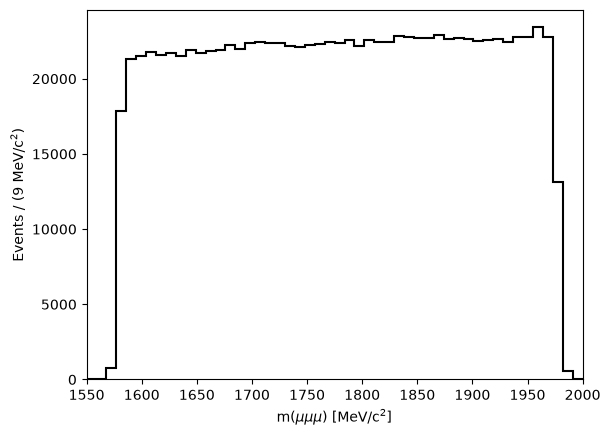

In [27]:
from analysis_helpers.plotting import plot_hist
fig, ax = plot_hist(df.Tau_M, bins=50, range=(1550, 2000), name=r'm($\mu\mu\mu$)', unit=r'MeV/c$^2$') 

In [28]:
import matplotlib.pyplot as plt

(<Axes: xlabel='$P_T$($\\mu\\mu\\mu$) [MeV/c]', ylabel='Events / (120 MeV/c)'>,
 <Axes: xlabel='$P_T$($\\mu\\mu\\mu$) [MeV/c]', ylabel='Events / (120 MeV/c)'>)

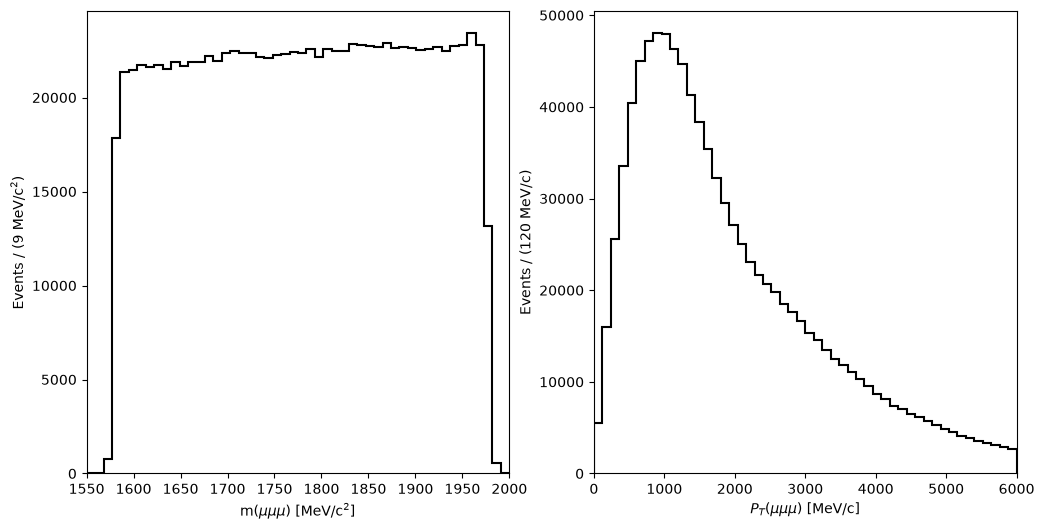

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
plot_hist(df.Tau_M, bins=50, range=(1550, 2000), name=r'm($\mu\mu\mu$)', unit=r'MeV/c$^2$', ax=ax[0]) 
plot_hist(df.Tau_PT, bins=50, range=(0, 6000), name=r'$P_T$($\mu\mu\mu$)', unit=r'MeV/c', ax=ax[1]) 